# PROJET STOCK MARKET - PREDICTION DE EARNINGS


# Introduction

L'objectif de ce notebook est d'évaluer le meilleur modèle d'apprentissage supervisé pour la prédiction des earnings du S&P 500. Pour cela, nous allons explorer plusieurs architectures étudiées dans le cours de modélisation statistique, à savoir la régression linéaire simple et la régression linéaire multiple.
Ensuite, nous développerons deux modèles de deep learning : un réseau neuronal simple et un réseau basé sur des couches LSTM.
Enfin, nous analyserons comment les données réagissent à ces modèles à l'aide de visualisations et de métriques telles que le MAE et la fonction de perte (loss).

# 1. Outils

Cette partie présente les outils nécessaires à notre étude, notamment les librairies utilisées, les paramètres ainsi que les fonctions. Ensuite, les données sont importées depuis notre base de données SQL fournie sur notre GitHub.

## 1.1 Librairies 

In [106]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mysql.connector
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from data_windowing import WindowGenerator


## 1.2 Parametres

In [156]:

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

INPUT_WIDTH = 5
LABEL_WIDTH = 1
SHIFT = 1

P_VAL = 0.1
P_TEST = 0.1

EPOCHS = 40
BATCH_SIZE = 12

FIGSIZE = (12, 6)


## 1.3 Connexion a la base de donnees

In [108]:
config = {
    "user": "root",
    "password": "root",
    "host": "localhost",
    "database": "sdd4",
    "raise_on_warnings": True
}

bdd = mysql.connector.connect(**config)


## 1.4 Fonctions

### 1.4.1 Importation des donnees 

In [109]:

def import_financialbehavior_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM financial_behavior")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df = df.set_index("idTB")

    return df 

def import_tweets_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM tweets")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("idT")

    return df 

def import_bigmacindex_table(bdd) -> pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bigmacindex")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idBM")

    return df 

def import_bitcoinperformance_table(bdd) ->pd.DataFrame: 
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM bitcoinperformance")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    for columns in df.columns: 
        if columns != "observation_date": 
            df[columns] = df[columns].astype(float)
    df = df.set_index("idB")

    return df 

def import_sp500_table(bdd)->pd.DataFrame:
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM standardandpoor")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns = columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df = df.set_index("idSP")

    return df

def import_inflation_table(bdd) ->pd.DataFrame:

    cursor = bdd.cursor()
    cursor = bdd.cursor()
    cursor.execute("SELECT * FROM inflation")
    columns = [col[0] for col in cursor.description]
    df = pd.DataFrame(cursor.fetchall(),columns=columns)
    df["observation_date"] = pd.to_datetime(df["observation_date"])
    df["CPI"] = df["CPI"].astype(float)
    df = df.set_index("idI")

    return df

def import_joinTable(bdd,*args:pd.DataFrame): 
    df = import_sp500_table(bdd)
    for table in args: 
        df = df.merge(table,on = "observation_date",how = "inner")

    
    return df

def standar_df(df:pd.DataFrame): 
    for columns in df.columns: 
        df[columns] = (df[columns] - df[columns].mean())/df[columns].std()
    
    return df



### 1.4.2 Fonctions de plotting 

In [ ]:

    
def plot_prediction(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.training_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.training_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test(wg: WindowGenerator, model: tf.keras.Sequential,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):

    plt.figure(figsize=FIGSIZE)
 
    y_pred = model.predict(wg.test_input).flatten()
    y_pred = (y_pred + mean) * std  

   
    y_real = wg.test_label.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()

def plot_prediction_test_general(wg: WindowGenerator, model: tf.keras.Sequential,label_encoder:int = None,
                    mean: float = MEAN_EARNINGS, std: float = STD_EARNINGS):
    
    if label_encoder is not None:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width,2)
    else:
        x,y = wg.split(wg.raw_df.to_numpy(),wg.input_width,wg.shift,wg.label_width)

    plt.figure(figsize=FIGSIZE)

    y_pred = model.predict(x).flatten()
    y_pred = (y_pred + mean) * std  

    y_real = y.flatten()
    y_real = (y_real + mean) * std  

    plt.plot(y_pred, label="Predicted")
    plt.plot(y_real, label="Real")
    plt.legend()
    plt.show()


def plot_bar_metrics(metrics:str,models:dict,title:str = None):
    plt.figure(figsize=FIGSIZE)
    height = []
    for keys in models.keys():
        if keys != "Baseline":
            height.append(models[keys].history[metrics][-1])
        else:
            height.append(models[keys][metrics])
    plt.bar(models.keys(),height)

    if title: 
        plt.title(title)
    else:
        plt.title(f"{metrics} of models")

    plt.show()

def plot_training_validation(history:dict,metrics:str,title:str = None): 
    plt.figure(figsize=FIGSIZE)

    if metrics == "loss":
        plt.plot(history["val_loss"],label="val loss")
        plt.plot(history["loss"],label = "loss")
    elif metrics == "mae": 
        plt.plot(history["mae_loss"],label="mae loss")
        plt.plot(history["mae"],label = "mae")

    if title:
        plt.title(title)
        
    plt.legend()
    plt.show()

# 2. Modeles 


## 2.1 Pretraitement de données 

Pour réaliser du forecasting, il est nécessaire de traiter les données d’une manière spécifique. Les algorithmes apprennent généralement à l’aide de fenêtres (windows). Une fenêtre consiste à prendre une séquence de données, par exemple les données du S&P 500 du lundi au mardi comme variables d’entrée, et celles du mercredi comme variable cible pour l’entraînement.
Dans cette perspective, on introduit également la notion de shift, qui correspond au décalage temporel entre chaque fenêtre. Dans cette étude, comme nous travaillons avec des modèles de régression linéaire, et par convention, nous utilisons un shift de 1. 

Avant d’effectuer le windowing, nous allons standardiser les données afin de les convertir en z-scores. Le z-score est une mesure qui représente l’écart d’une observation par rapport à la moyenne générale, exprimé en nombre d’écarts-types. Par exemple, une valeur de -1 indique que l’observation se situe un écart-type en dessous de la moyenne (la moyenne étant égale à 0 après standardisation).Cette transformation permet aux algorithmes d’analyser les données sans rencontrer de problèmes d’échelle.

In [157]:
df = import_sp500_table(bdd)
sp = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

target_col = "earnings"

features = [
    "sp500",
    "dividend",
    "earnings",
    "longInterestRate"
]

df_model = sp[features].copy()

df_model




,sp500,dividend,earnings,longInterestRate
idSP,,,,
2,-0.461055,-0.528404,-0.496333,0.367589
3,-0.461074,-0.528404,-0.496333,0.361070
4,-0.460938,-0.528404,-0.496333,0.365416
5,-0.460777,-0.528404,-0.496333,0.365416
6,-0.460629,-0.528404,-0.496333,0.365416
...,...,...,...,...
1830,4.658198,4.392132,4.579796,-0.399512
1831,4.904417,4.404383,4.636586,-0.321281
1832,5.105533,4.404383,4.636586,-0.256088


## 2.1.2 Window Generator 

Sur notre GitHub, vous pouvez retrouver la classe WindowGenerator que nous avons développée afin de créer les fenêtres nécessaires à la préparation des données.
Nous définissons deux objets WindowGenerator. Un pour les modèles linéaires et les réseaux de neurones dense, pour lesquels les données doivent être présentées sous forme de matrices 2D (observations × variables), et un autre pour le modèle LSTM, qui nécessite des données sous forme de tenseurs 3D (observations × pas de temps × variables).
Cette distinction est essentielle, car les modèles séquentiels comme les LSTM exploitent explicitement la dimension temporelle, contrairement aux modèles linéaires et aux réseaux dense.

In [ ]:
target_index = df_model.columns.get_loc(target_col)

wg_lstm = WindowGenerator(
    df=df_model,
    input_width=INPUT_WIDTH,
    shift=SHIFT,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=LABEL_WIDTH,
    label_encoder= target_index
)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

wg_linear_uni_variable = WindowGenerator(
    df=df_model["earnings"],
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
)



# 3. Modeles

## 3.1 Baseline

In [113]:


class BaselinePredictor:

    def __init__(self, shift: int = 1, target_index: int = 0):
        self.shift = shift
        self.target_index = target_index

    def fit(self, X: np.ndarray, y: np.ndarray):
        
        self.X_train_ = X
        self.y_train_ = y
    
        if self.shift == 1:
            y_pred = X[-1,self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

        y_pred = y_pred.reshape(-1)
        y_true = y.flatten()

        loss = np.mean((y_true - y_pred) ** 2)
        mae = np.mean(np.abs(y_true - y_pred))

        self.history = {'loss': loss, 'mae': mae}

        return self.history


    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.shift == 1:
            y_pred = X[-1, self.target_index]
        else:
            y_pred = X[-self.shift, self.target_index]

 
        return y_pred
        






## 3.2 Modèles d’apprentissage supervisé

In [ ]:

def build_linear_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_dense_model(input_shape):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


def build_lstm_model(input_shape):
        
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(32, activation='tanh',return_sequences=True),  
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.LSTM(32, activation='tanh'), 
        tf.keras.layers.Dropout(0.2), 

        tf.keras.layers.Dense(1)             
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model




In [115]:

print(wg_lstm.training_label.flatten().shape)
print(wg_lstm.training_input.shape)


(1460,)
(1460, 5, 4)


In [116]:

print(wg_linear.training_label.shape)
print(wg_linear.training_input.shape)


(1464,)
(1464, 4)


In [117]:
class StopIfValLossRepeated(tf.keras.callbacks.Callback):

    def __init__(self, max_repeats=3):
        super().__init__()
        self.max_repeats = max_repeats
        self.last_val_loss = None
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get("val_loss")

        
        if self.last_val_loss is not None and current_val_loss >= self.last_val_loss:
            self.counter += 1
        else:
            self.counter = 0 

        self.last_val_loss = current_val_loss

        if self.counter >= self.max_repeats:
            print("Stopping: val_loss repeated too many times")
            self.model.stop_training = True
            self.last_val_loss = None
            self.counter = 0

callback = StopIfValLossRepeated(max_repeats=10)

In [118]:
model = BaselinePredictor()
history_baseline = model.fit(wg_linear.training_input,wg_linear.training_label)

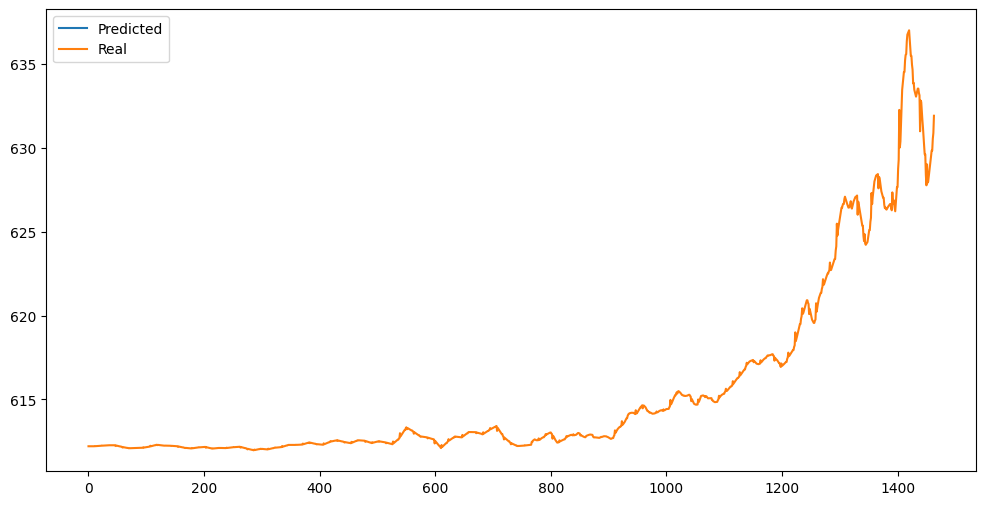

In [119]:
plot_prediction(wg_linear,model)

In [120]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3179 - mae: 0.3914 - val_loss: 0.1421 - val_mae: 0.3376
Epoch 2/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2072 - mae: 0.3022 - val_loss: 0.1255 - val_mae: 0.3002
Epoch 3/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1308 - mae: 0.2383 - val_loss: 0.1529 - val_mae: 0.2943
Epoch 4/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0797 - mae: 0.1858 - val_loss: 0.2009 - val_mae: 0.3312
Epoch 5/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0474 - mae: 0.1431 - val_loss: 0.2524 - val_mae: 0.3780
Epoch 6/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0282 - mae: 0.1110 - val_loss: 0.2955 - val_mae: 0.4167
Epoch 7/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0174 - mae: 0.0907 - val_loss: 0.3239 - val_mae: 0.4458
Epoch 8/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0117 - mae: 0.0775 - val_loss: 0.3357 - val_mae: 0.4597
Epoch 9/120
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


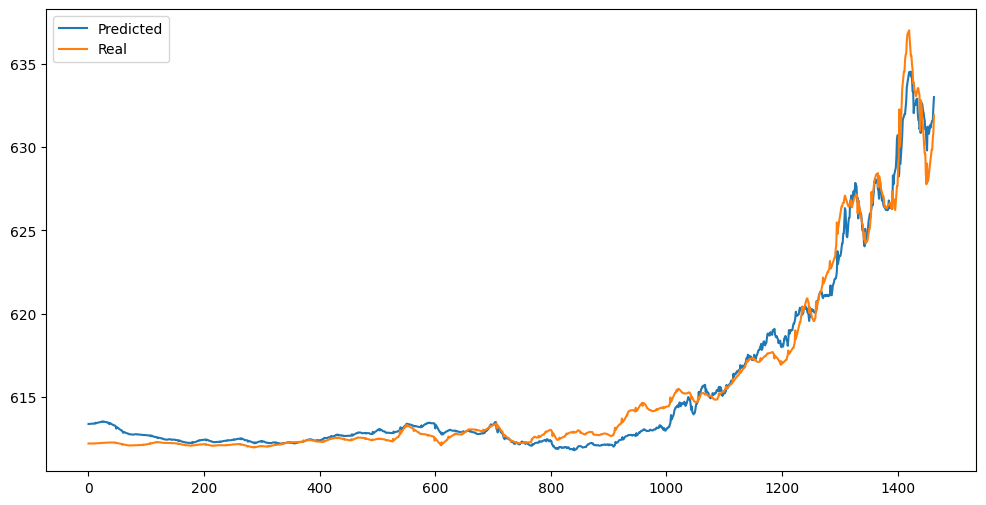

In [121]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


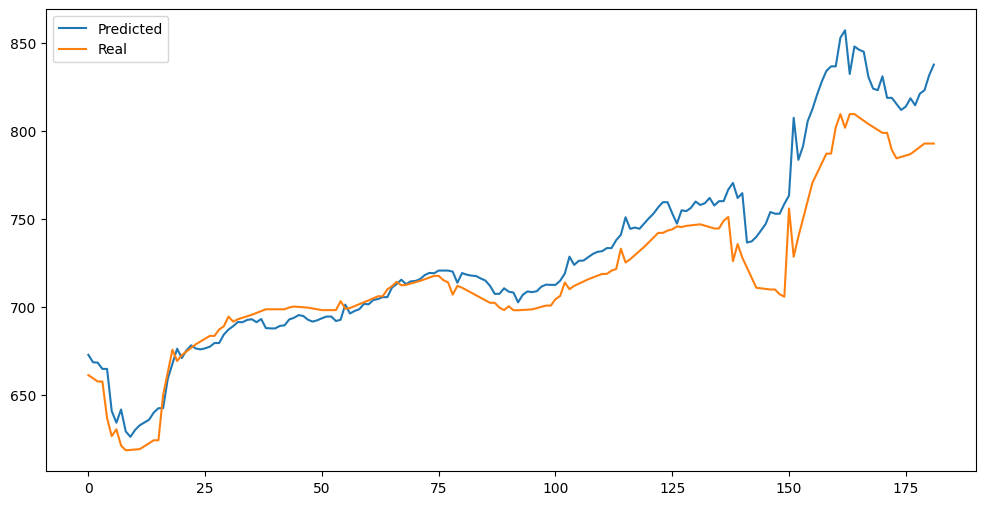

In [122]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step


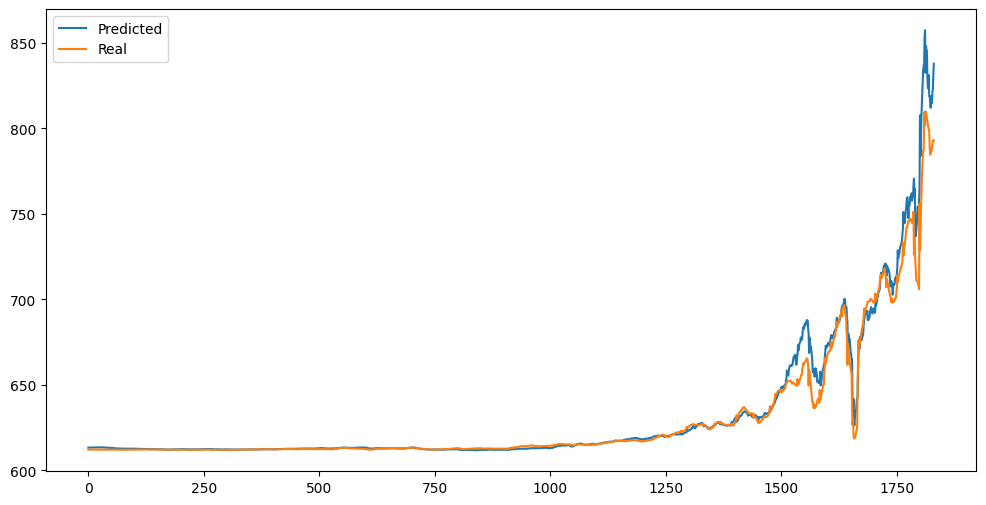

In [123]:
plot_prediction_test_general(wg_linear,model,2)

In [124]:


model = build_linear_model(wg_linear_uni_variable.training_input.reshape(-1, 1).shape[1:])
history_linear_uni = model.fit(wg_linear_uni_variable.training_input.reshape(-1, 1),wg_linear_uni_variable.training_label,
                               epochs= 80 ,validation_data=(wg_linear_uni_variable.val_input, wg_linear_uni_variable.val_label), batch_size= BATCH_SIZE,callbacks=[callback])

Epoch 1/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5207 - mae: 0.6831 - val_loss: 2.7753 - val_mae: 1.4352
Epoch 2/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3311 - mae: 0.5431 - val_loss: 2.7575 - val_mae: 1.4576
Epoch 3/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2052 - mae: 0.4308 - val_loss: 2.7395 - val_mae: 1.4746
Epoch 4/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1271 - mae: 0.3405 - val_loss: 2.7173 - val_mae: 1.4854
Epoch 5/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0819 - mae: 0.2700 - val_loss: 2.6879 - val_mae: 1.4899
Epoch 6/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0578 - mae: 0.2182 - val_loss: 2.6491 - val_mae: 1.4881
Epoch 7/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0459 - mae: 0.1817 - val_loss: 2.6002 - val_mae: 1.4805
Epoch 8/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0401 - mae: 0.1589 - val_loss: 2.5417 - val_mae: 1.4678
Epoch 9/80
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


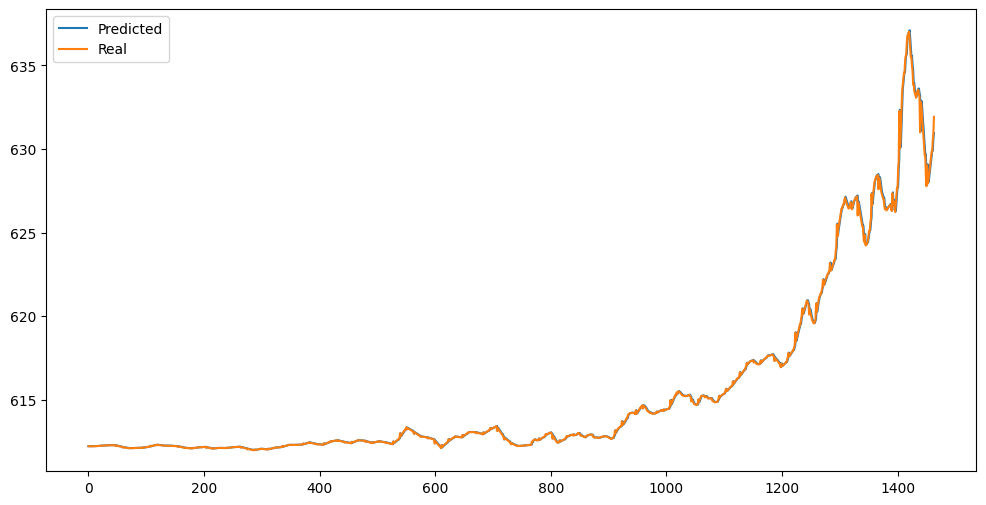

In [125]:
plot_prediction(wg_linear_uni_variable,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


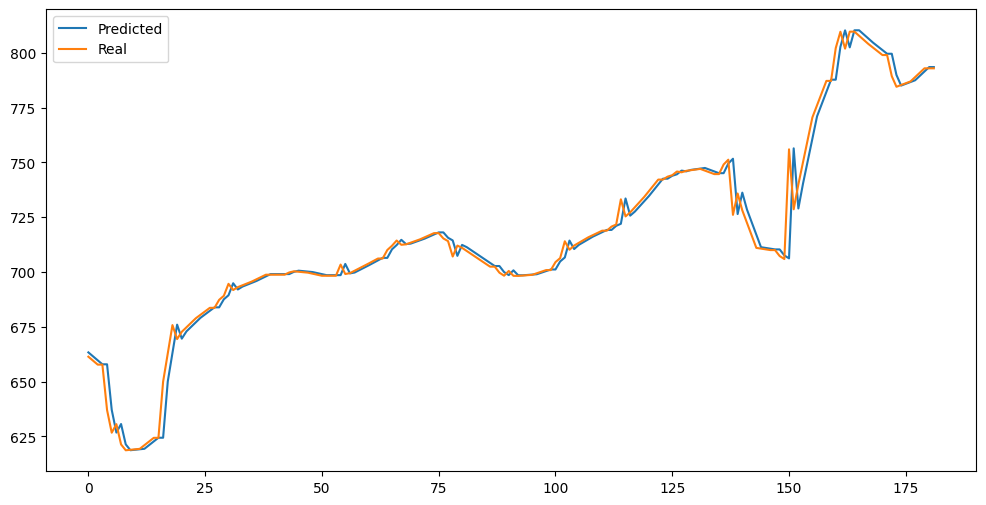

In [126]:
plot_prediction_test(wg_linear_uni_variable,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


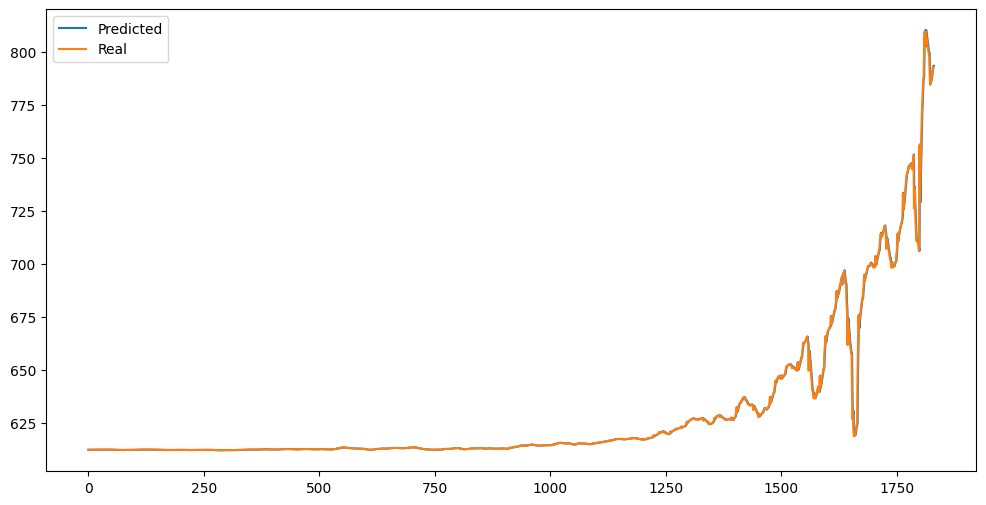

In [127]:
plot_prediction_test_general(wg_linear_uni_variable,model)

In [128]:
model = build_dense_model(wg_linear.training_input.shape[1:])
history_dense = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= EPOCHS,
                          validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1733 - mae: 0.3165 - val_loss: 0.7254 - val_mae: 0.7344
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0670 - mae: 0.1966 - val_loss: 0.6979 - val_mae: 0.7138
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0445 - mae: 0.1593 - val_loss: 0.6960 - val_mae: 0.7187
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0262 - mae: 0.1235 - val_loss: 0.7085 - val_mae: 0.7326
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0192 - mae: 0.1069 - val_loss: 0.7129 - val_mae: 0.7368
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0168 - mae: 0.0981 - val_loss: 0.7323 - val_mae: 0.7530
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0140 - mae: 0.0908 - val_loss: 0.7471 - val_mae: 0.7659
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0113 - mae: 0.0810 - val_loss: 0.7579 - val_mae: 0.7762
Epoch 9/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


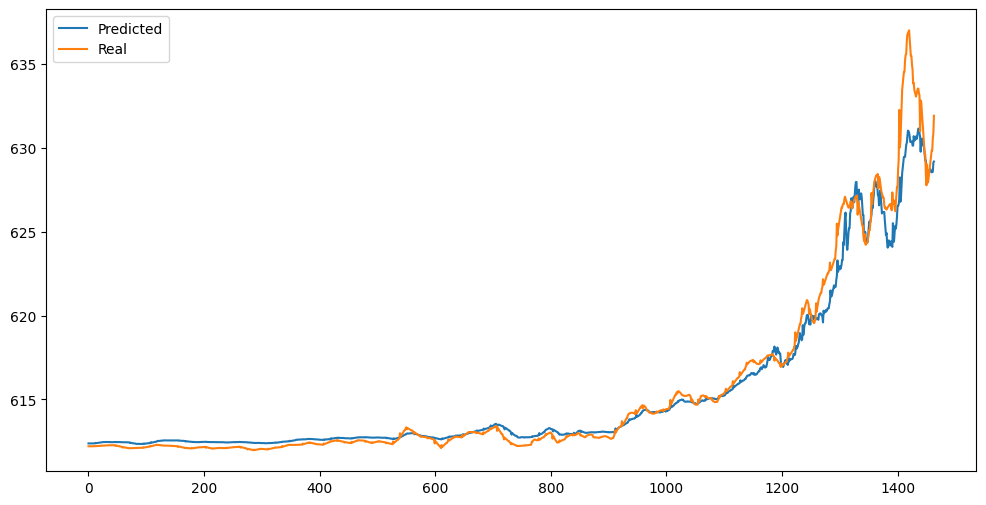

In [129]:
plot_prediction(wg_linear,model)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


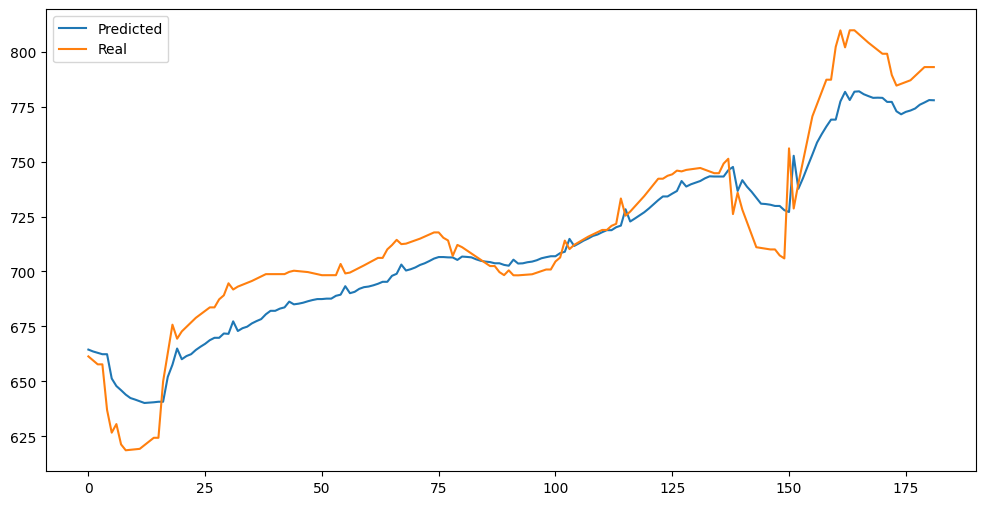

In [130]:
plot_prediction_test(wg_linear,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 795us/step


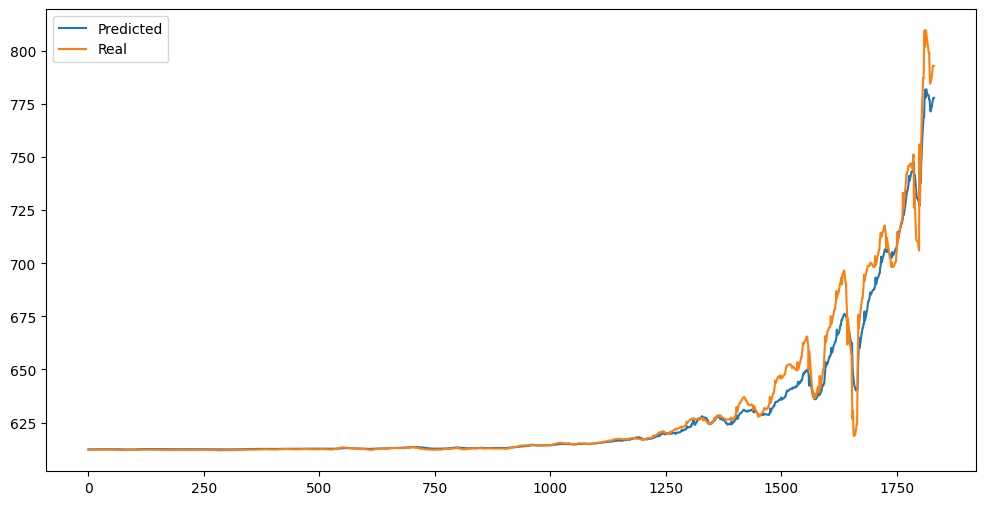

In [131]:
plot_prediction_test_general(wg_linear,model,2)

In [132]:
model = build_lstm_model(wg_lstm.training_input.shape[1:])
history_lstm = model.fit(wg_lstm.training_tf,validation_data=wg_lstm.val_tf,epochs= EPOCHS,callbacks=[callback])

Epoch 1/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0425 - mae: 0.1589 - val_loss: 0.5357 - val_mae: 0.6124
Epoch 2/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0157 - mae: 0.1029 - val_loss: 0.5219 - val_mae: 0.6102
Epoch 3/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0115 - mae: 0.0851 - val_loss: 0.5132 - val_mae: 0.6028
Epoch 4/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117 - mae: 0.0883 - val_loss: 0.4885 - val_mae: 0.5828
Epoch 5/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - mae: 0.0636 - val_loss: 0.5036 - val_mae: 0.6005
Epoch 6/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0055 - mae: 0.0593 - val_loss: 0.4506 - val_mae: 0.5579
Epoch 7/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0043 - mae: 0.0513 - val_loss: 0.4334 - val_mae: 0.5468
Epoch 8/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0039 - mae: 0.0483 - val_loss: 0.3985 - val_mae: 0.5189
Epoch 9/40
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - mae:

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


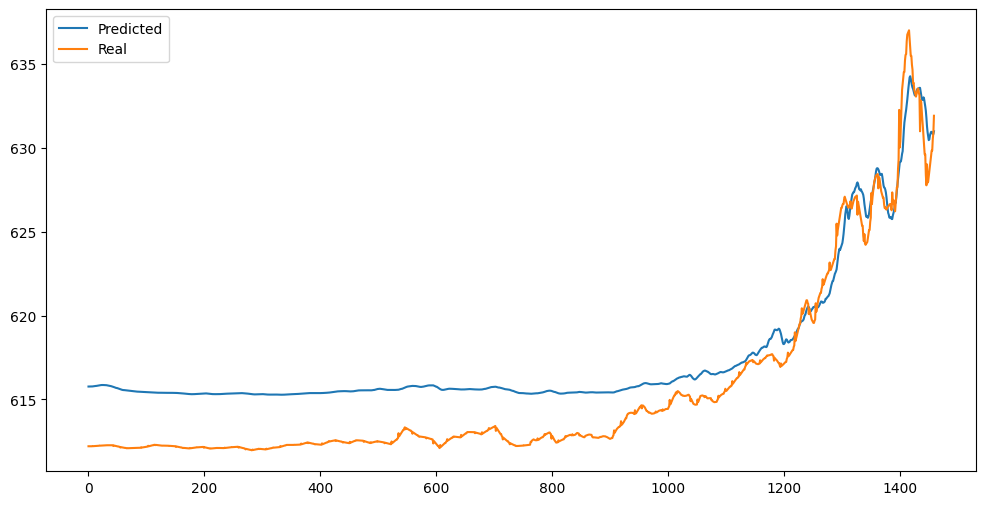

In [133]:
plot_prediction(wg_lstm,model)

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


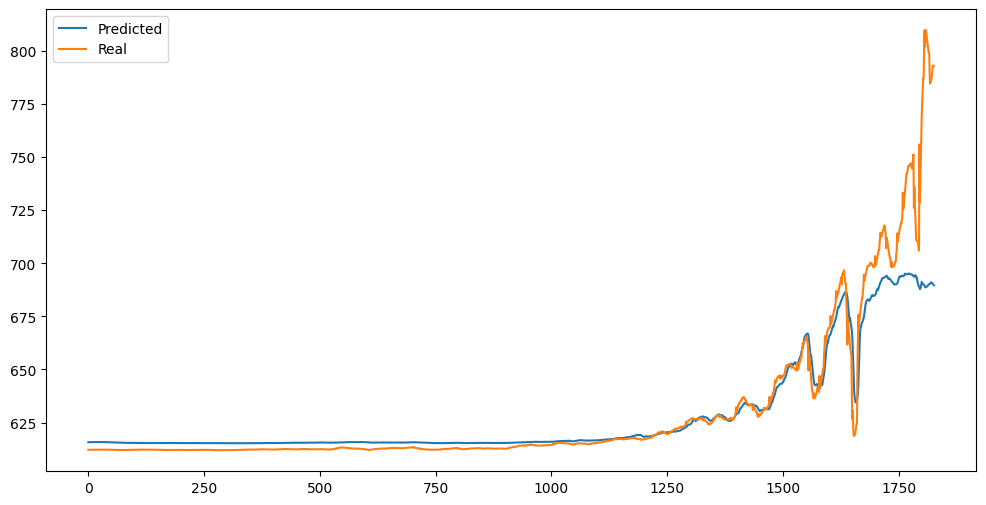

In [134]:
plot_prediction_test_general(wg_lstm,model,2)

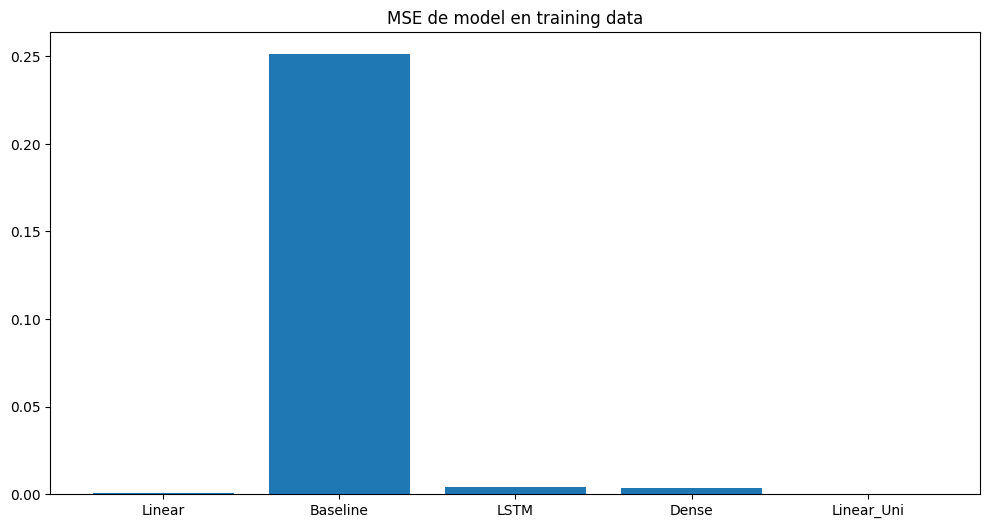

In [135]:
models = {
    "Linear": history_linear,
    "Baseline": history_baseline,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}



models_val = {
    "Linear": history_linear,
    "LSTM": history_lstm,
    "Dense": history_dense,
    "Linear_Uni": history_linear_uni
}

plot_bar_metrics("loss", models,"MSE de model en training data")

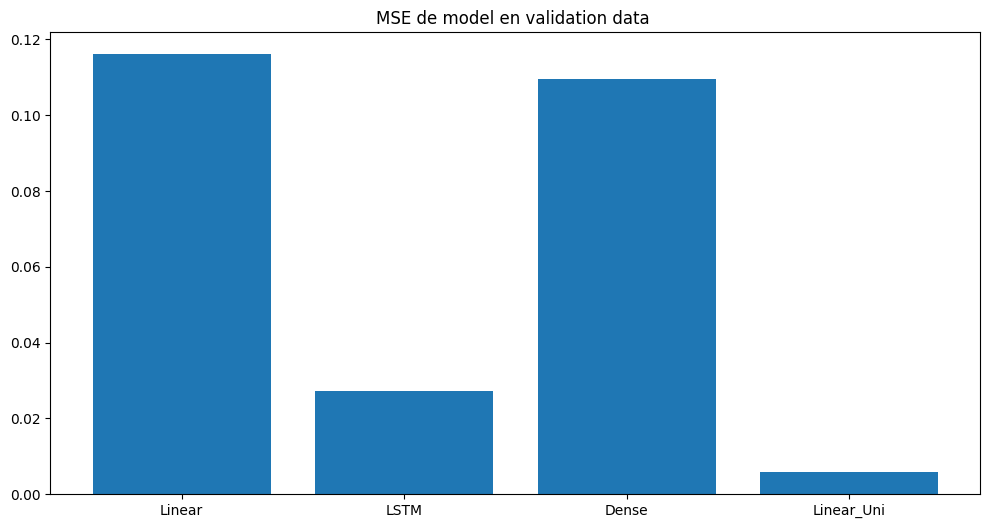

In [136]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

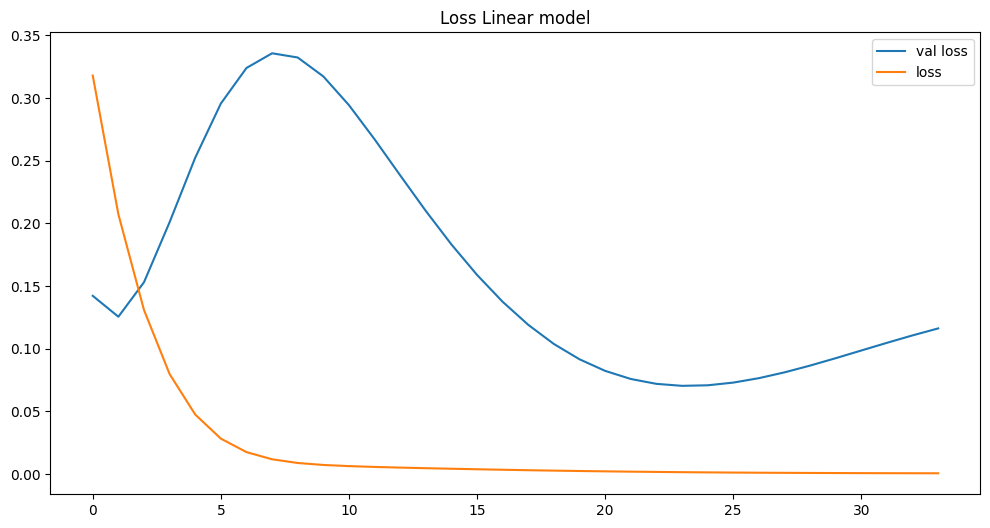

In [137]:
plot_training_validation(models_val["Linear"].history,"loss","Loss Linear model")

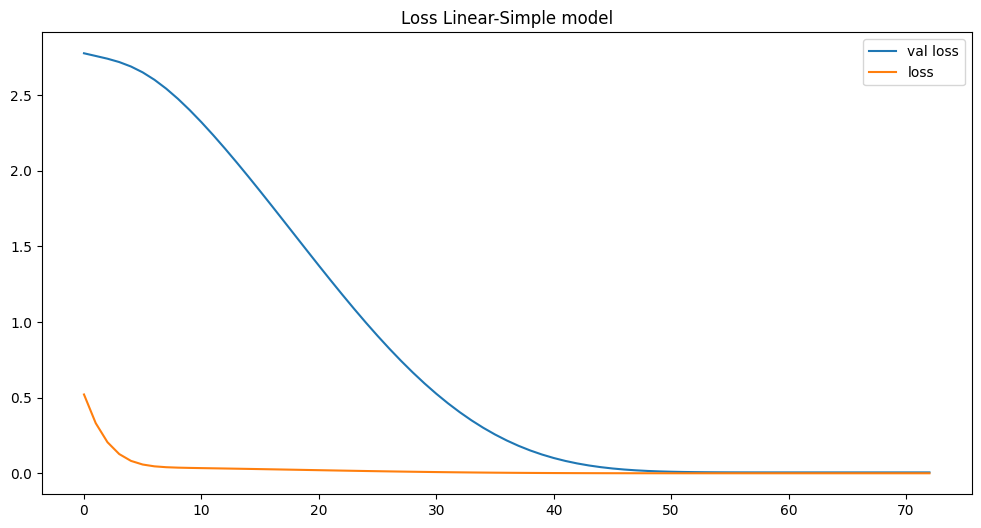

In [138]:
plot_training_validation(models_val["Linear_Uni"].history,"loss","Loss Linear-Simple model")

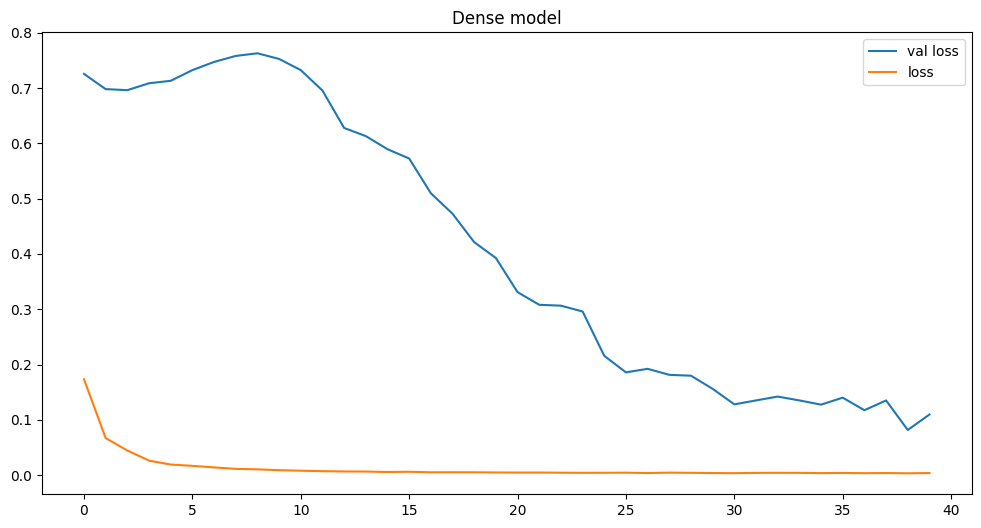

In [139]:
plot_training_validation(models_val["Dense"].history,"loss","Dense model")

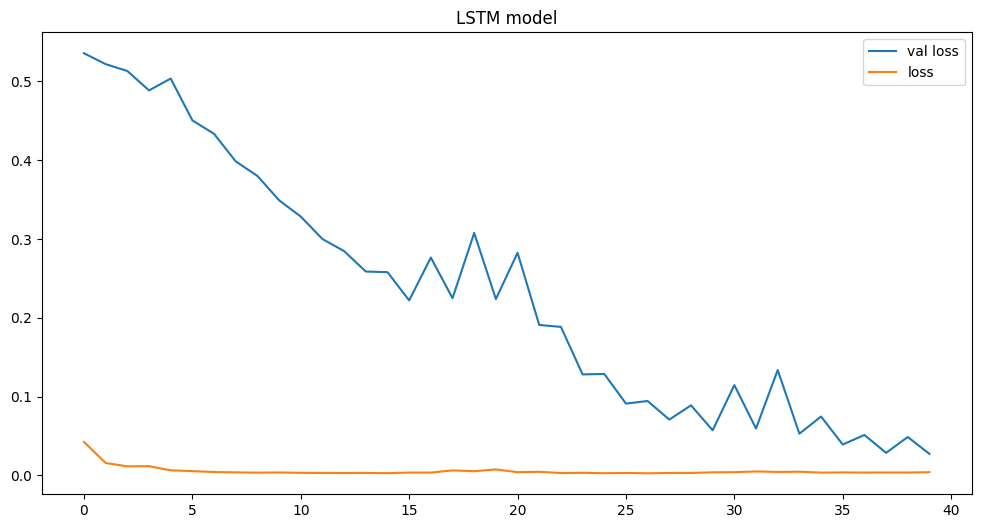

In [140]:
plot_training_validation(models_val["LSTM"].history,"loss","LSTM model")

In [141]:

df = import_joinTable(bdd,import_inflation_table(bdd))

df_model = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

In [142]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [143]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation"] = history_linear_inflation

Epoch 1/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2742 - mae: 0.4046 - val_loss: 0.4993 - val_mae: 0.6763
Epoch 2/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1630 - mae: 0.3081 - val_loss: 0.5702 - val_mae: 0.7285
Epoch 3/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1031 - mae: 0.2509 - val_loss: 0.5625 - val_mae: 0.7247
Epoch 4/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0705 - mae: 0.2105 - val_loss: 0.5037 - val_mae: 0.6846
Epoch 5/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0517 - mae: 0.1815 - val_loss: 0.4176 - val_mae: 0.6204
Epoch 6/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392 - mae: 0.1586 - val_loss: 0.3261 - val_mae: 0.5440
Epoch 7/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0300 - mae: 0.1389 - val_loss: 0.2434 - val_mae: 0.4643
Epoch 8/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0229 - mae: 0.1212 - val_loss: 0.1763 - val_mae: 0.3877
Epoch 9/120
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.017

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


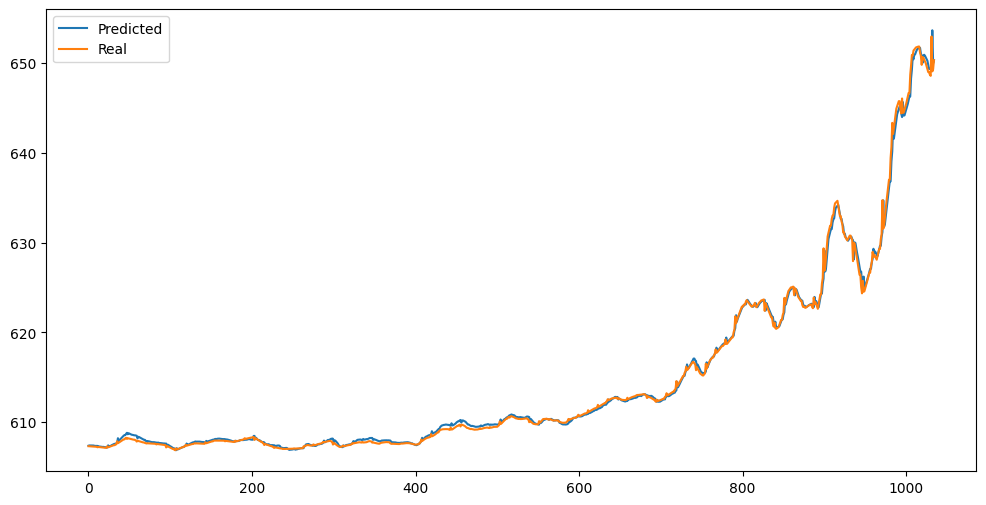

In [144]:
plot_prediction(wg_linear,model)


41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step


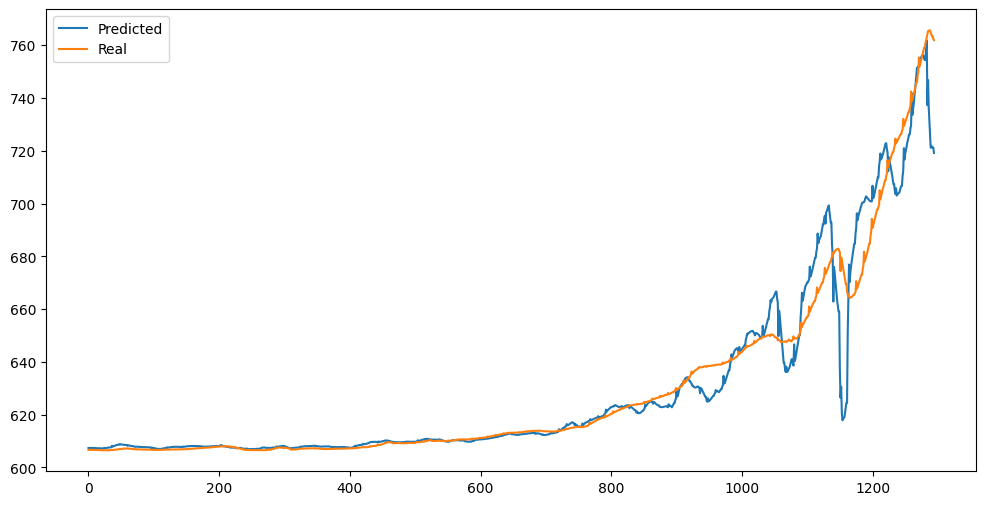

In [145]:
plot_prediction_test_general(wg_linear,model,target_index)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


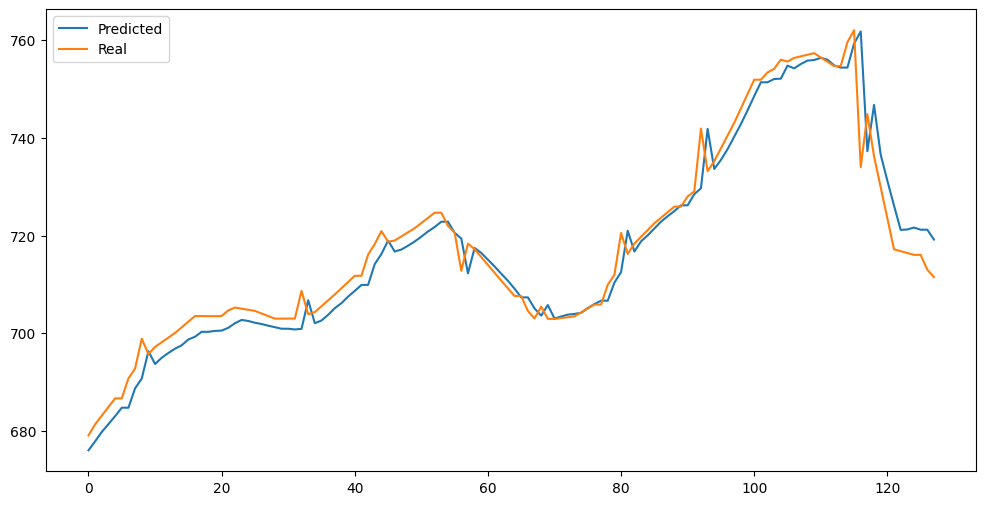

In [146]:
plot_prediction_test(wg_linear,model)

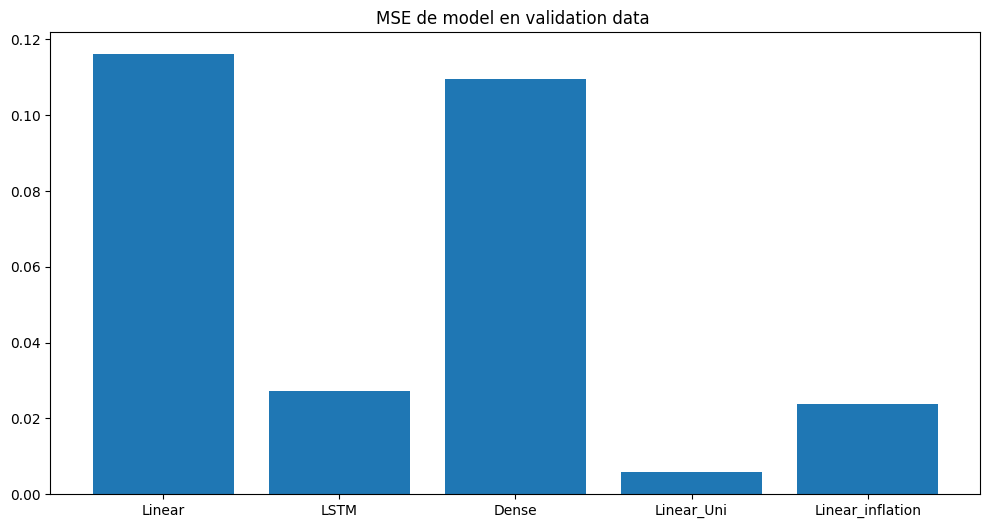

In [147]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")

In [148]:

df = import_joinTable(bdd,import_inflation_table(bdd),import_bigmacindex_table(bdd))

df_model = standar_df(df.copy())


MEAN_EARNINGS = df["earnings"].mean()
STD_EARNINGS = df["earnings"].std()

In [149]:
target_index = df_model.columns.get_loc(target_col)

wg_linear = WindowGenerator(
    df=df_model,
    input_width=1,
    shift=1,
    p_val_df=P_VAL,
    p_test_df=P_TEST,
    label_width=1,
    label_encoder= target_index
)

In [150]:

model = build_linear_model(wg_linear.training_input.shape[1:])
history_linear_inflation = model.fit(wg_linear.training_input,wg_linear.training_label,epochs= 120,
                           validation_data=(wg_linear.val_input, wg_linear.val_label),batch_size=BATCH_SIZE,callbacks=[callback])

models_val["Linear_inflation_bigmac"] = history_linear_inflation

Epoch 1/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.7834 - mae: 0.6250 - val_loss: 0.4468 - val_mae: 0.4815
Epoch 2/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7207 - mae: 0.5917 - val_loss: 0.4765 - val_mae: 0.5164
Epoch 3/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6648 - mae: 0.5626 - val_loss: 0.4950 - val_mae: 0.5430
Epoch 4/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6141 - mae: 0.5359 - val_loss: 0.5016 - val_mae: 0.5583
Epoch 5/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5679 - mae: 0.5116 - val_loss: 0.4982 - val_mae: 0.5646
Epoch 6/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5255 - mae: 0.4886 - val_loss: 0.4876 - val_mae: 0.5644
Epoch 7/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4866 - mae: 0.4669 - val_loss: 0.4722 - val_mae: 0.5597
Epoch 8/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4508 - mae: 0.4462 - val_loss: 0.4540 - val_mae: 0.5520
Epoch 9/120
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.41

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


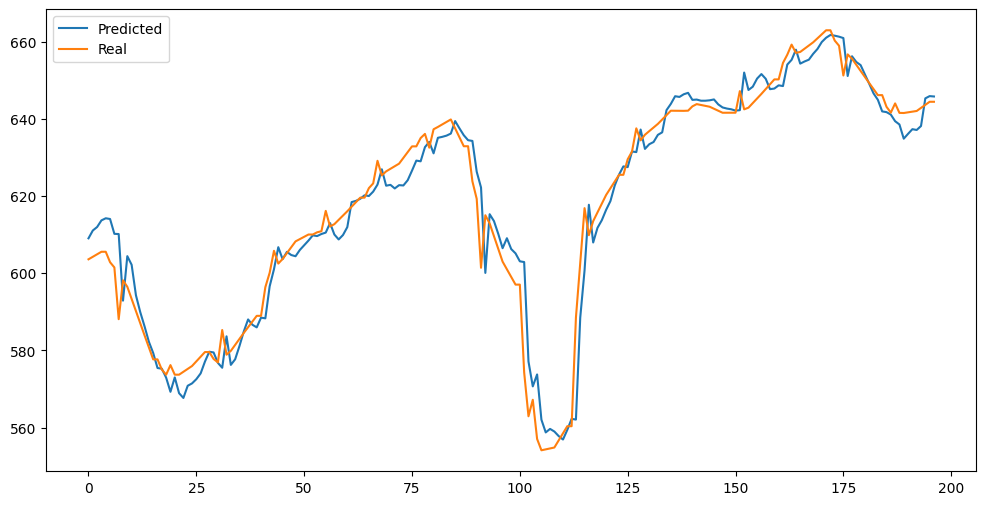

In [151]:
plot_prediction(wg_linear,model)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


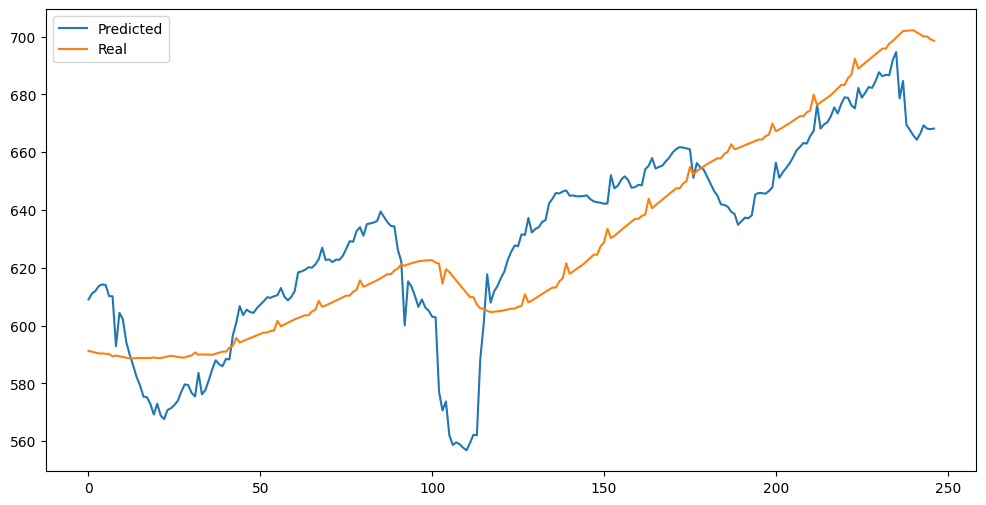

In [155]:
plot_prediction_test_general(wg_linear,model,target_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


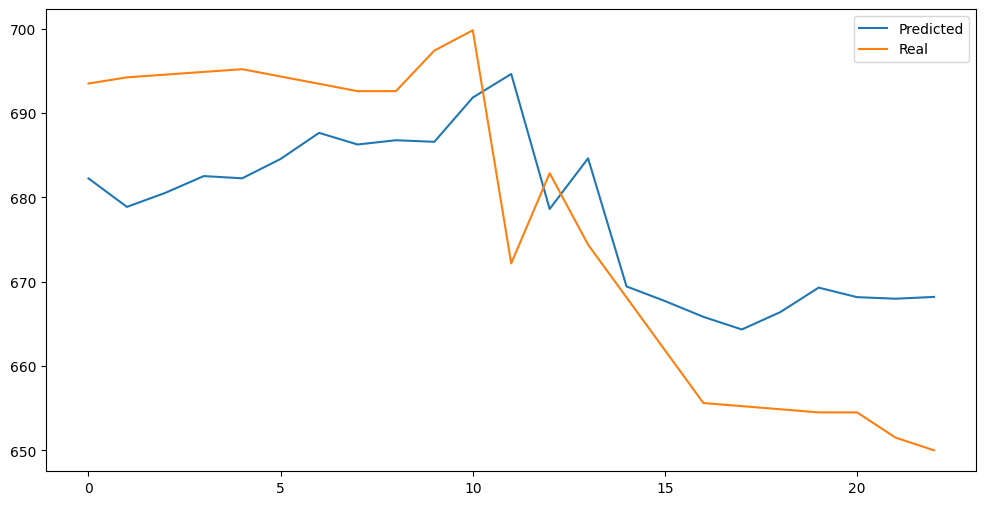

In [153]:
plot_prediction_test(wg_linear,model)

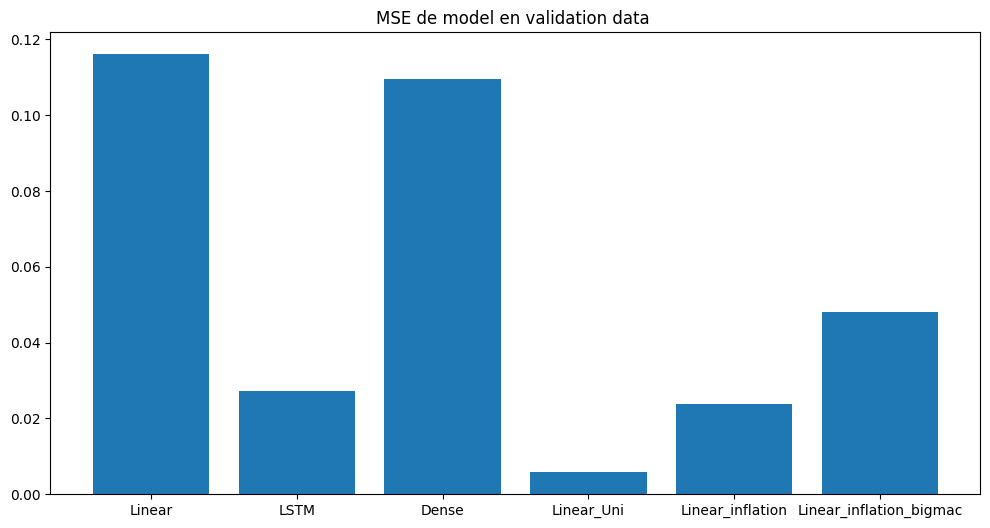

In [154]:
plot_bar_metrics("val_loss", models_val,"MSE de model en validation data ")